In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harrywang/wine-dataset-for-clustering")

print("Path to dataset files:", path)

100%|██████████| 4.36k/4.36k [00:00<00:00, 4.81MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harrywang/wine-dataset-for-clustering/versions/1


In [4]:
import os

os.listdir(path)

['wine-clustering.csv']

In [5]:
wine = pd.read_csv(os.path.join(path, 'wine-clustering.csv'))

wine.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


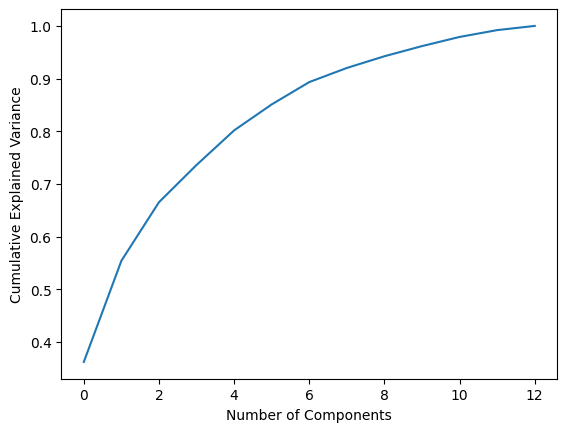

5


In [6]:
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine)

pca = PCA()
pca.fit(wine_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

n_components = np.argmax(explained_variance >= 0.80) + 1

print(n_components)

pca = PCA(n_components=n_components)
wine_pca = pca.fit_transform(wine_scaled)

In [7]:
pca_table = pd.DataFrame({
    'Component': range(1, len(pca.explained_variance_ratio_) + 1),
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

pca_table

,Component,Explained Variance Ratio,Cumulative Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623


In [8]:
inertia = []
silhouette_scores = []
k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(wine_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(wine_pca, labels))

kmeans_results = pd.DataFrame({
    'k': list(k_values),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})

kmeans_results

,k,Inertia,Silhouette Score
0,2,1201.157500,0.323917
1,3,825.020838,0.369076
2,4,723.935749,0.325619
3,5,663.988882,0.264530
4,6,605.376056,0.272779
5,7,558.113912,0.275598


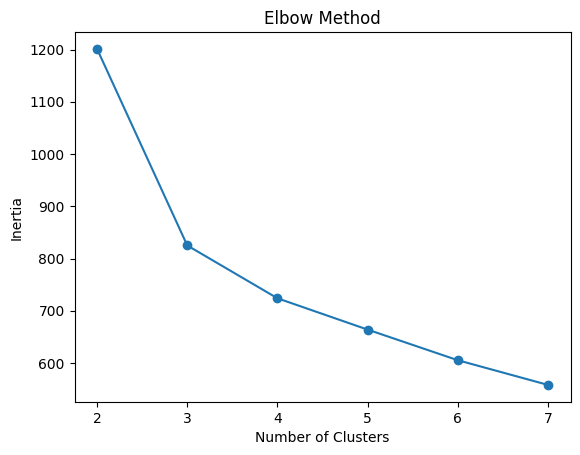

In [9]:
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

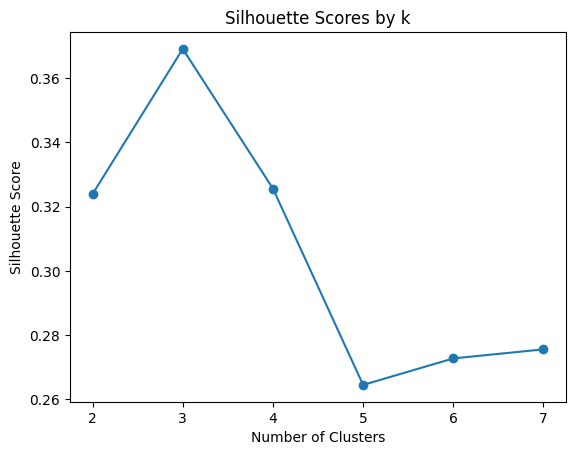

In [10]:
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores by k')
plt.show()

In [11]:
best_k = kmeans_results.loc[kmeans_results['Silhouette Score'].idxmax(), 'k']

best_k

np.int64(3)

In [12]:
kmeans_final = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(wine_pca)

wine['KMeans_Cluster'] = kmeans_labels

wine['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,65
2,62
1,51


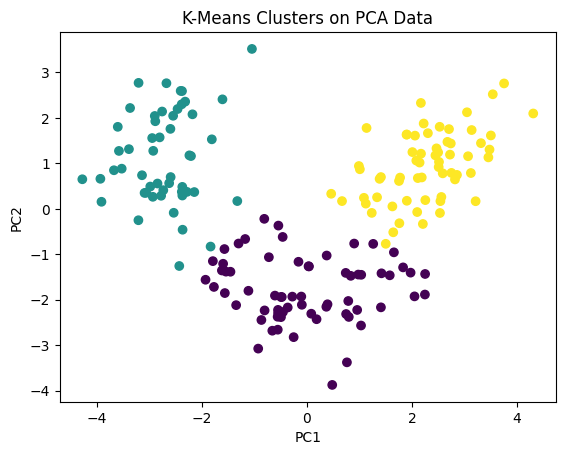

In [13]:
plt.scatter(wine_pca[:, 0], wine_pca[:, 1], c=kmeans_labels)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA Data')
plt.show()

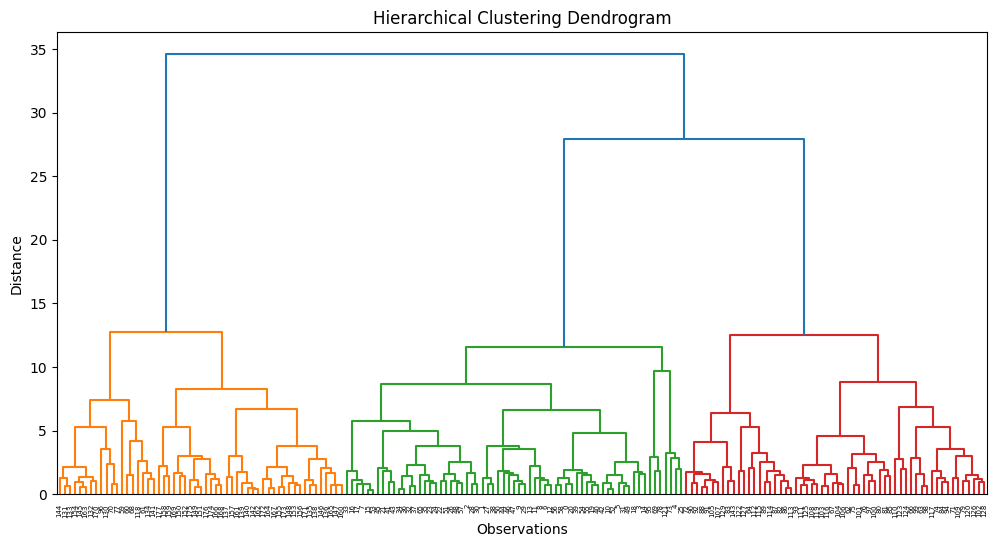

In [14]:
linked = linkage(wine_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()

In [15]:
hierarchical = AgglomerativeClustering(n_clusters=int(best_k), linkage='ward')
hierarchical_labels = hierarchical.fit_predict(wine_pca)

wine['Hierarchical_Cluster'] = hierarchical_labels

wine['Hierarchical_Cluster'].value_counts()

,count
Hierarchical_Cluster,
2,65
1,58
0,55


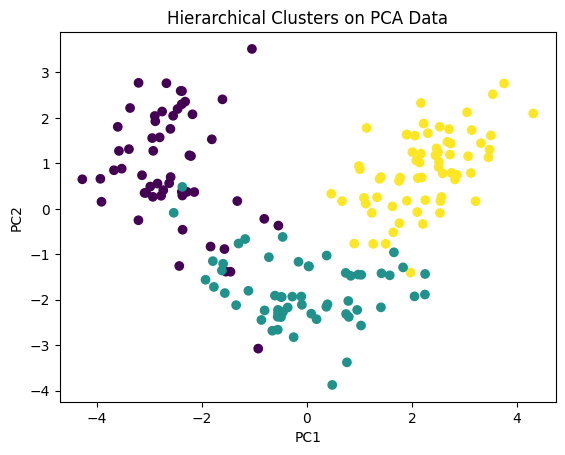

In [16]:
plt.scatter(wine_pca[:, 0], wine_pca[:, 1], c=hierarchical_labels)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clusters on PCA Data')
plt.show()

In [17]:
pd.crosstab(wine['KMeans_Cluster'], wine['Hierarchical_Cluster'])

Hierarchical_Cluster,0,1,2
KMeans_Cluster,,,
0,6,56,3
1,49,2,0
2,0,0,62


In [18]:
cluster_summary = wine.groupby('KMeans_Cluster').mean()

cluster_summary

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Hierarchical_Cluster
KMeans_Cluster,,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231,0.953846
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,0.039216
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806,2.000000


In [19]:
print("Number of PCA components needed for 80% variance:", n_components)
print("Best k based on silhouette score:", best_k)
print("K-means silhouette score:", max(silhouette_scores))

Number of PCA components needed for 80% variance: 5
Best k based on silhouette score: 3
K-means silhouette score: 0.3690763194699229


In [20]:
pd.crosstab(wine['KMeans_Cluster'], wine['Hierarchical_Cluster'])

Hierarchical_Cluster,0,1,2
KMeans_Cluster,,,
0,6,56,3
1,49,2,0
2,0,0,62


In [21]:
wine.groupby('KMeans_Cluster').mean()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Hierarchical_Cluster
KMeans_Cluster,,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231,0.953846
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,0.039216
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806,2.000000


In [22]:
print("PCA Components (80% variance):", n_components)
print("Best k:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

PCA Components (80% variance): 5
Best k: 3
Best Silhouette Score: 0.3690763194699229
